start matrix: 
[[0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 0]
 [0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 1 1 1 0 1]
 [0 0 1 0 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1]
 [1 0 1 0 1 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0]
 [1 1 1 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 1 1]
 [1 1 1 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1]
 [0 0 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1]
 [1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0]
 [0 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 0 1 1 0]
 [0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0]
 [0 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1]
 [0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 1]
 [1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1]
 [1 0 0 0 1 1 0 0 0 0 1 1 1 1 1 0 0 1 0 1]
 [0 1 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 1 0]
 [0 1 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1]
 [1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0]
 [0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1]
 [1 1 1 0 1 0 0 1 1 0 1 1 0 1 1 0 1 0 0 0]]

end matrix
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 

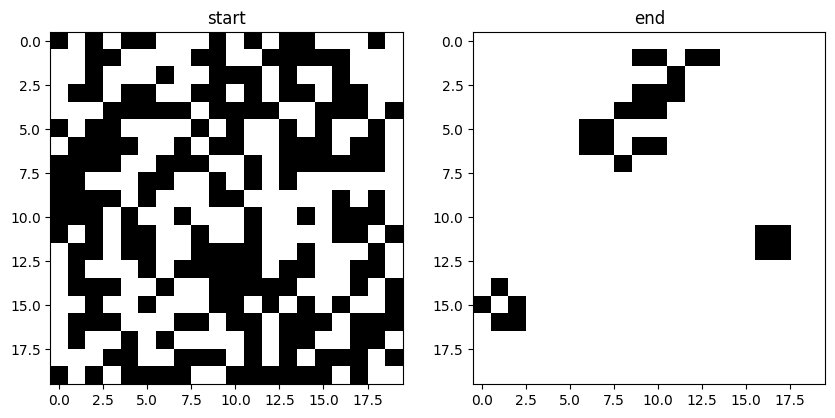

In [11]:
import numpy as np
import matplotlib.pyplot as plt

SIZE = 20
STEPS = 20

grid = np.random.randint(2, size=(SIZE, SIZE))
first_grid = grid.copy()

print(f"start matrix: \n{first_grid}")


# count 8 neighbors
def count_neighbors(grid, x, y):
    total = 0
    for i in range(-1, 2):
        for j in range(-1, 2):

            if i == 0 and j == 0:
                continue

            nx = x + i
            ny = y + j

            if 0 <= nx < SIZE and 0 <= ny < SIZE:
                total += grid[nx][ny]
    return total


# rules
def step(grid):

    new_grid = grid.copy()

    for x in range(SIZE):
        for y in range(SIZE):

            neighbors = count_neighbors(grid, x, y)

            # alive
            if grid[x][y] == 1:
                if neighbors < 2:
                    new_grid[x][y] = 0
                elif neighbors > 3:
                    new_grid[x][y] = 0

            # dead
            else:
                if neighbors == 3:
                    new_grid[x][y] = 1

    return new_grid


history = [grid]
for _ in range(STEPS):
    grid = step(grid)
    history.append(grid)

final_grid = grid

print("\nend matrix")
print(final_grid)


# visualization
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(first_grid, cmap="binary")
axes[0].set_title("start")

axes[1].imshow(final_grid, cmap="binary")
axes[1].set_title("end")

plt.show()